# Physics Integrator Benchmark — Analysis & Visualisation

Analyses two CSV files produced by the C++ benchmark:
- **`benchmark.csv`** — aggregated metrics per (solver, dt)
- **`energy_drift.csv`** — E(t) time series for selected dt values

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy import stats

plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 11,
    }
)

SOLVER_STYLE = {
    "Euler": {"color": "#E24B4A", "marker": "o", "ls": "-"},
    "Verlet": {"color": "#378ADD", "marker": "s", "ls": "--"},
    "RK4": {"color": "#1D9E75", "marker": "^", "ls": "-."},
}

ABOX = dict(boxstyle="round,pad=0.4", fc="white", ec="#cccccc", alpha=0.92, lw=0.8)


def solver_legend(ax, loc="lower right"):
    handles = [
        Line2D(
            [0],
            [0],
            color=s["color"],
            marker=s["marker"],
            linestyle=s["ls"],
            label=name,
            markersize=6,
        )
        for name, s in SOLVER_STYLE.items()
    ]
    ax.legend(handles=handles, framealpha=0.5, loc=loc)


BENCHMARK_CSV = Path("benchmark.csv")
ENERGY_DRIFT_CSV = Path("energy_drift.csv")

df = pd.read_csv(BENCHMARK_CSV)
ede = pd.read_csv(ENERGY_DRIFT_CSV)
df_valid = df[df["max_height_error"] > 0].copy()

print(f"benchmark.csv    : {len(df)} rows")
print(f"energy_drift.csv : {len(ede)} rows")

benchmark.csv    : 150 rows
energy_drift.csv : 6597 rows


## Plot 1 — Contact time error vs dt (convergence order)

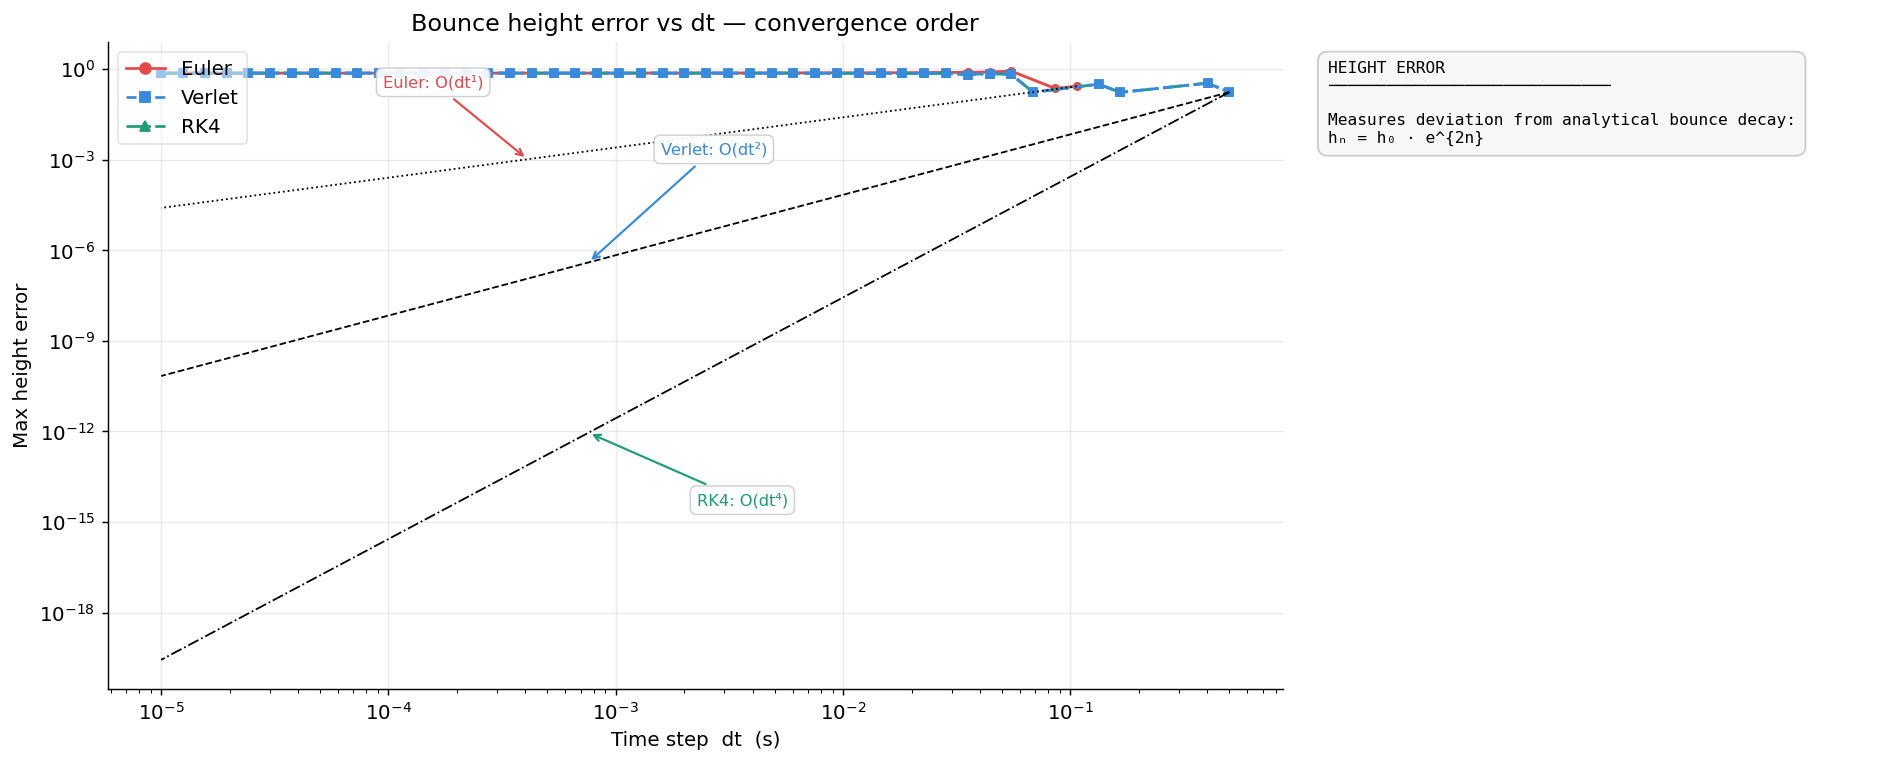

In [15]:
fig, (ax, ax_notes) = plt.subplots(
    1, 2, figsize=(15, 6),
    gridspec_kw={"width_ratios": [2, 1]}
)

for solver, grp in df_valid.groupby("solver"):
    s = SOLVER_STYLE[solver]
    grp = grp.sort_values("dt")

    ax.loglog(
        grp["dt"],
        grp["max_height_error"],
        color=s["color"],
        marker=s["marker"],
        ls=s["ls"],
        markersize=4,
        linewidth=1.6,
    )

# Reference slopes (anchored at last point)
orders = [1, 2, 4]
styles = ["k:", "k--", "k-."]
ref_lines = []

for i, (solver, grp) in enumerate(df_valid.groupby("solver")):
    grp = grp.sort_values("dt")

    dt_max = grp["dt"].iloc[-1]
    y0 = grp["max_height_error"].iloc[-1]
    p = orders[i]

    dt_ref = np.array([dt_max, grp["dt"].iloc[0]])
    y_ref = y0 * (dt_ref / dt_max) ** p

    ax.loglog(dt_ref, y_ref, styles[i], linewidth=1)

    ref_lines.append((dt_ref, y_ref))

def point_on_line(dt_ref, y_ref, t=0.6):
    x = dt_ref[0]**(1-t) * dt_ref[1]**t
    y = y_ref[0]**(1-t) * y_ref[1]**t
    return x, y

labels = ["Euler: O(dt¹)", "Verlet: O(dt²)", "RK4: O(dt⁴)"]
colors = ["#E24B4A", "#378ADD", "#1D9E75"]
offsets = [(-80, 40), (40, 60), (60, -40)]

for i in range(3):
    x, y = point_on_line(*ref_lines[i])
    ax.annotate(
        labels[i],
        xy=(x, y),
        xytext=offsets[i],
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->", color=colors[i], lw=1.2),
        color=colors[i],
        fontsize=9,
        bbox=ABOX,
    )

ax.set_xlabel("Time step  dt  (s)")
ax.set_ylabel("Max height error")
ax.set_title("Bounce height error vs dt — convergence order")

solver_legend(ax, loc="upper left")

ax_notes.axis("off")
ax_notes.text(
    0.04, 0.97,
    "HEIGHT ERROR\n─────────────────────────────\n\nMeasures deviation from analytical bounce decay:\nhₙ = h₀ · e^{2n}",
    transform=ax_notes.transAxes,
    fontsize=9,
    va="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc"),
)

plt.tight_layout()
plt.savefig("plot_convergence.png", dpi=150)
plt.show()

## Plot 2 — Max energy drift vs dt

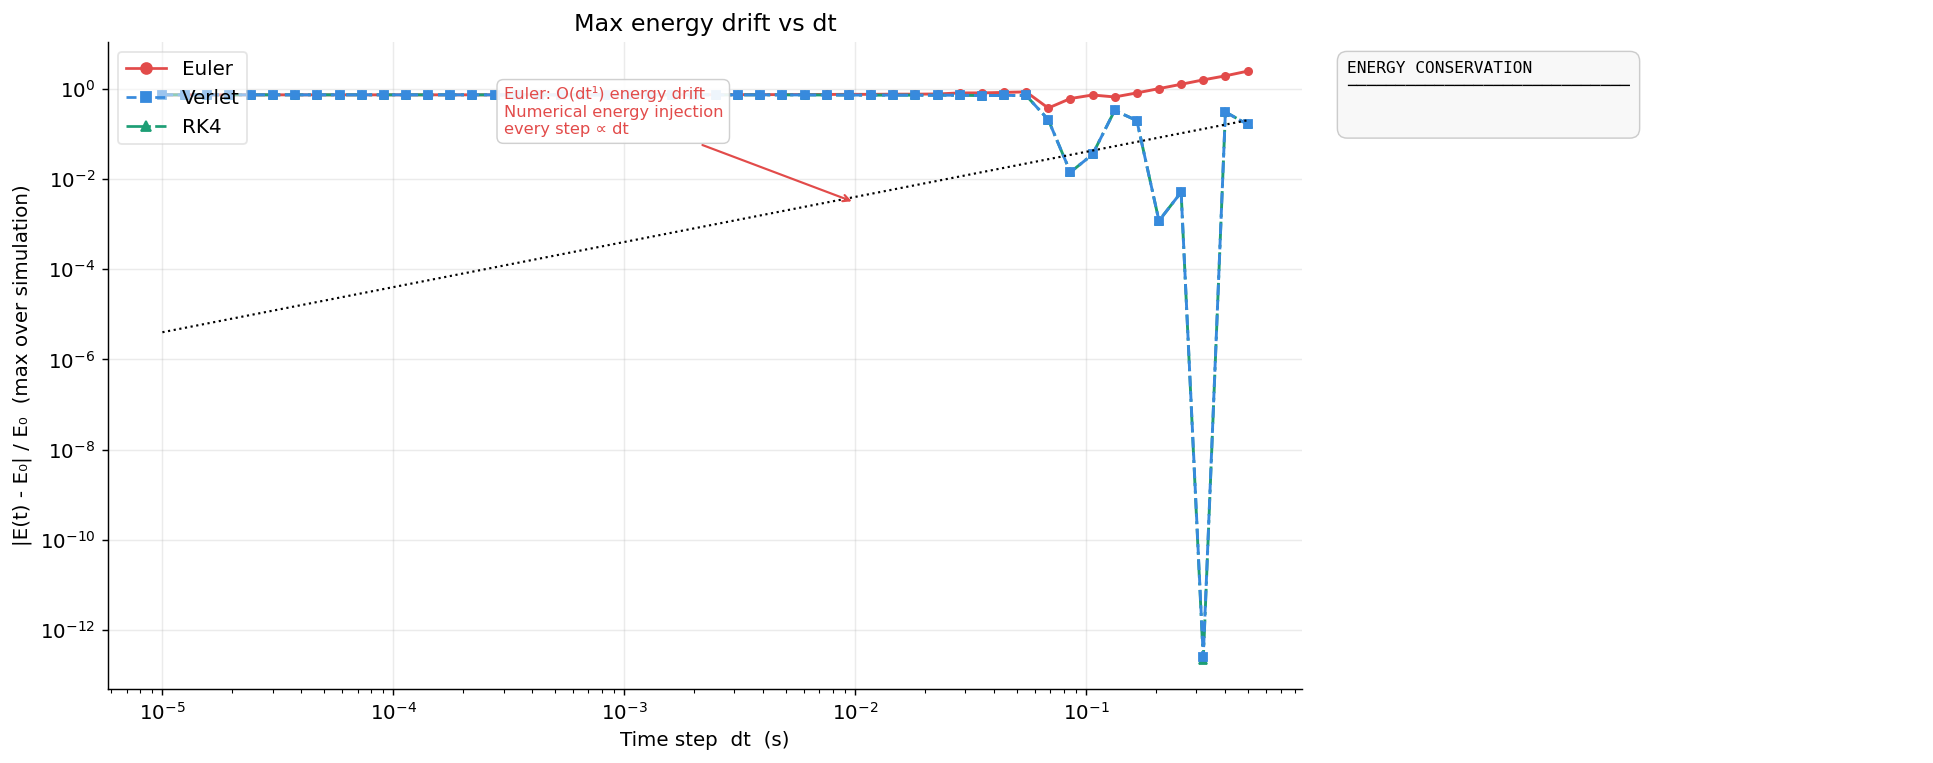

In [16]:
fig, (ax, ax_notes) = plt.subplots(
    1, 2, figsize=(15, 6),
    gridspec_kw={"width_ratios": [2, 1]}
)

for solver, grp in df.groupby("solver"):
    s = SOLVER_STYLE[solver]
    grp = grp.sort_values("dt")
    mask = grp["max_energy_drift"] > 0
    ax.loglog(grp.loc[mask, "dt"], grp.loc[mask, "max_energy_drift"],
              color=s["color"], marker=s["marker"], ls=s["ls"],
              markersize=4, linewidth=1.6)

# Reference O(dt) slope for Euler
dt_ref = np.array([1e-5, 5e-1])
ax.loglog(dt_ref, 4e-1 * dt_ref**1, "k:", linewidth=1.2, label="O(dt¹) ref")

# ── Annotations ──────────────────────────────────────────────────────────────
ax.annotate("Euler: O(dt¹) energy drift\nNumerical energy injection\nevery step ∝ dt",
            xy=(1e-2, 3e-3), xytext=(3e-4, 1e-1),
            arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1.2),
            color="#E24B4A", fontsize=9, bbox=ABOX)

ax.annotate("Verlet & RK4: machine precision\n~1e-11 to 1e-15 across all dt",
            xy=(1e-3, 3e-14), xytext=(1e-2, 1e-10),
            arrowprops=dict(arrowstyle="->", color="#378ADD", lw=1.2),
            color="#555", fontsize=9, bbox=ABOX)

ax.set_xlabel("Time step  dt  (s)")
ax.set_ylabel("|E(t) - E₀| / E₀  (max over simulation)")
ax.set_title("Max energy drift vs dt")
solver_legend(ax, loc="upper left")

# ── Side notes ────────────────────────────────────────────────────────────────
ax_notes.axis("off")
notes = (
    "ENERGY CONSERVATION\n"
    "─────────────────────────────\n\n"
)
ax_notes.text(0.04, 0.97, notes, transform=ax_notes.transAxes,
              fontsize=9, va="top", family="monospace",
              bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8))

plt.tight_layout()
plt.savefig("plot_energy_drift_vs_dt.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 3 — Cost vs precision

/tmp/ipykernel_203218/435203472.py:79: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


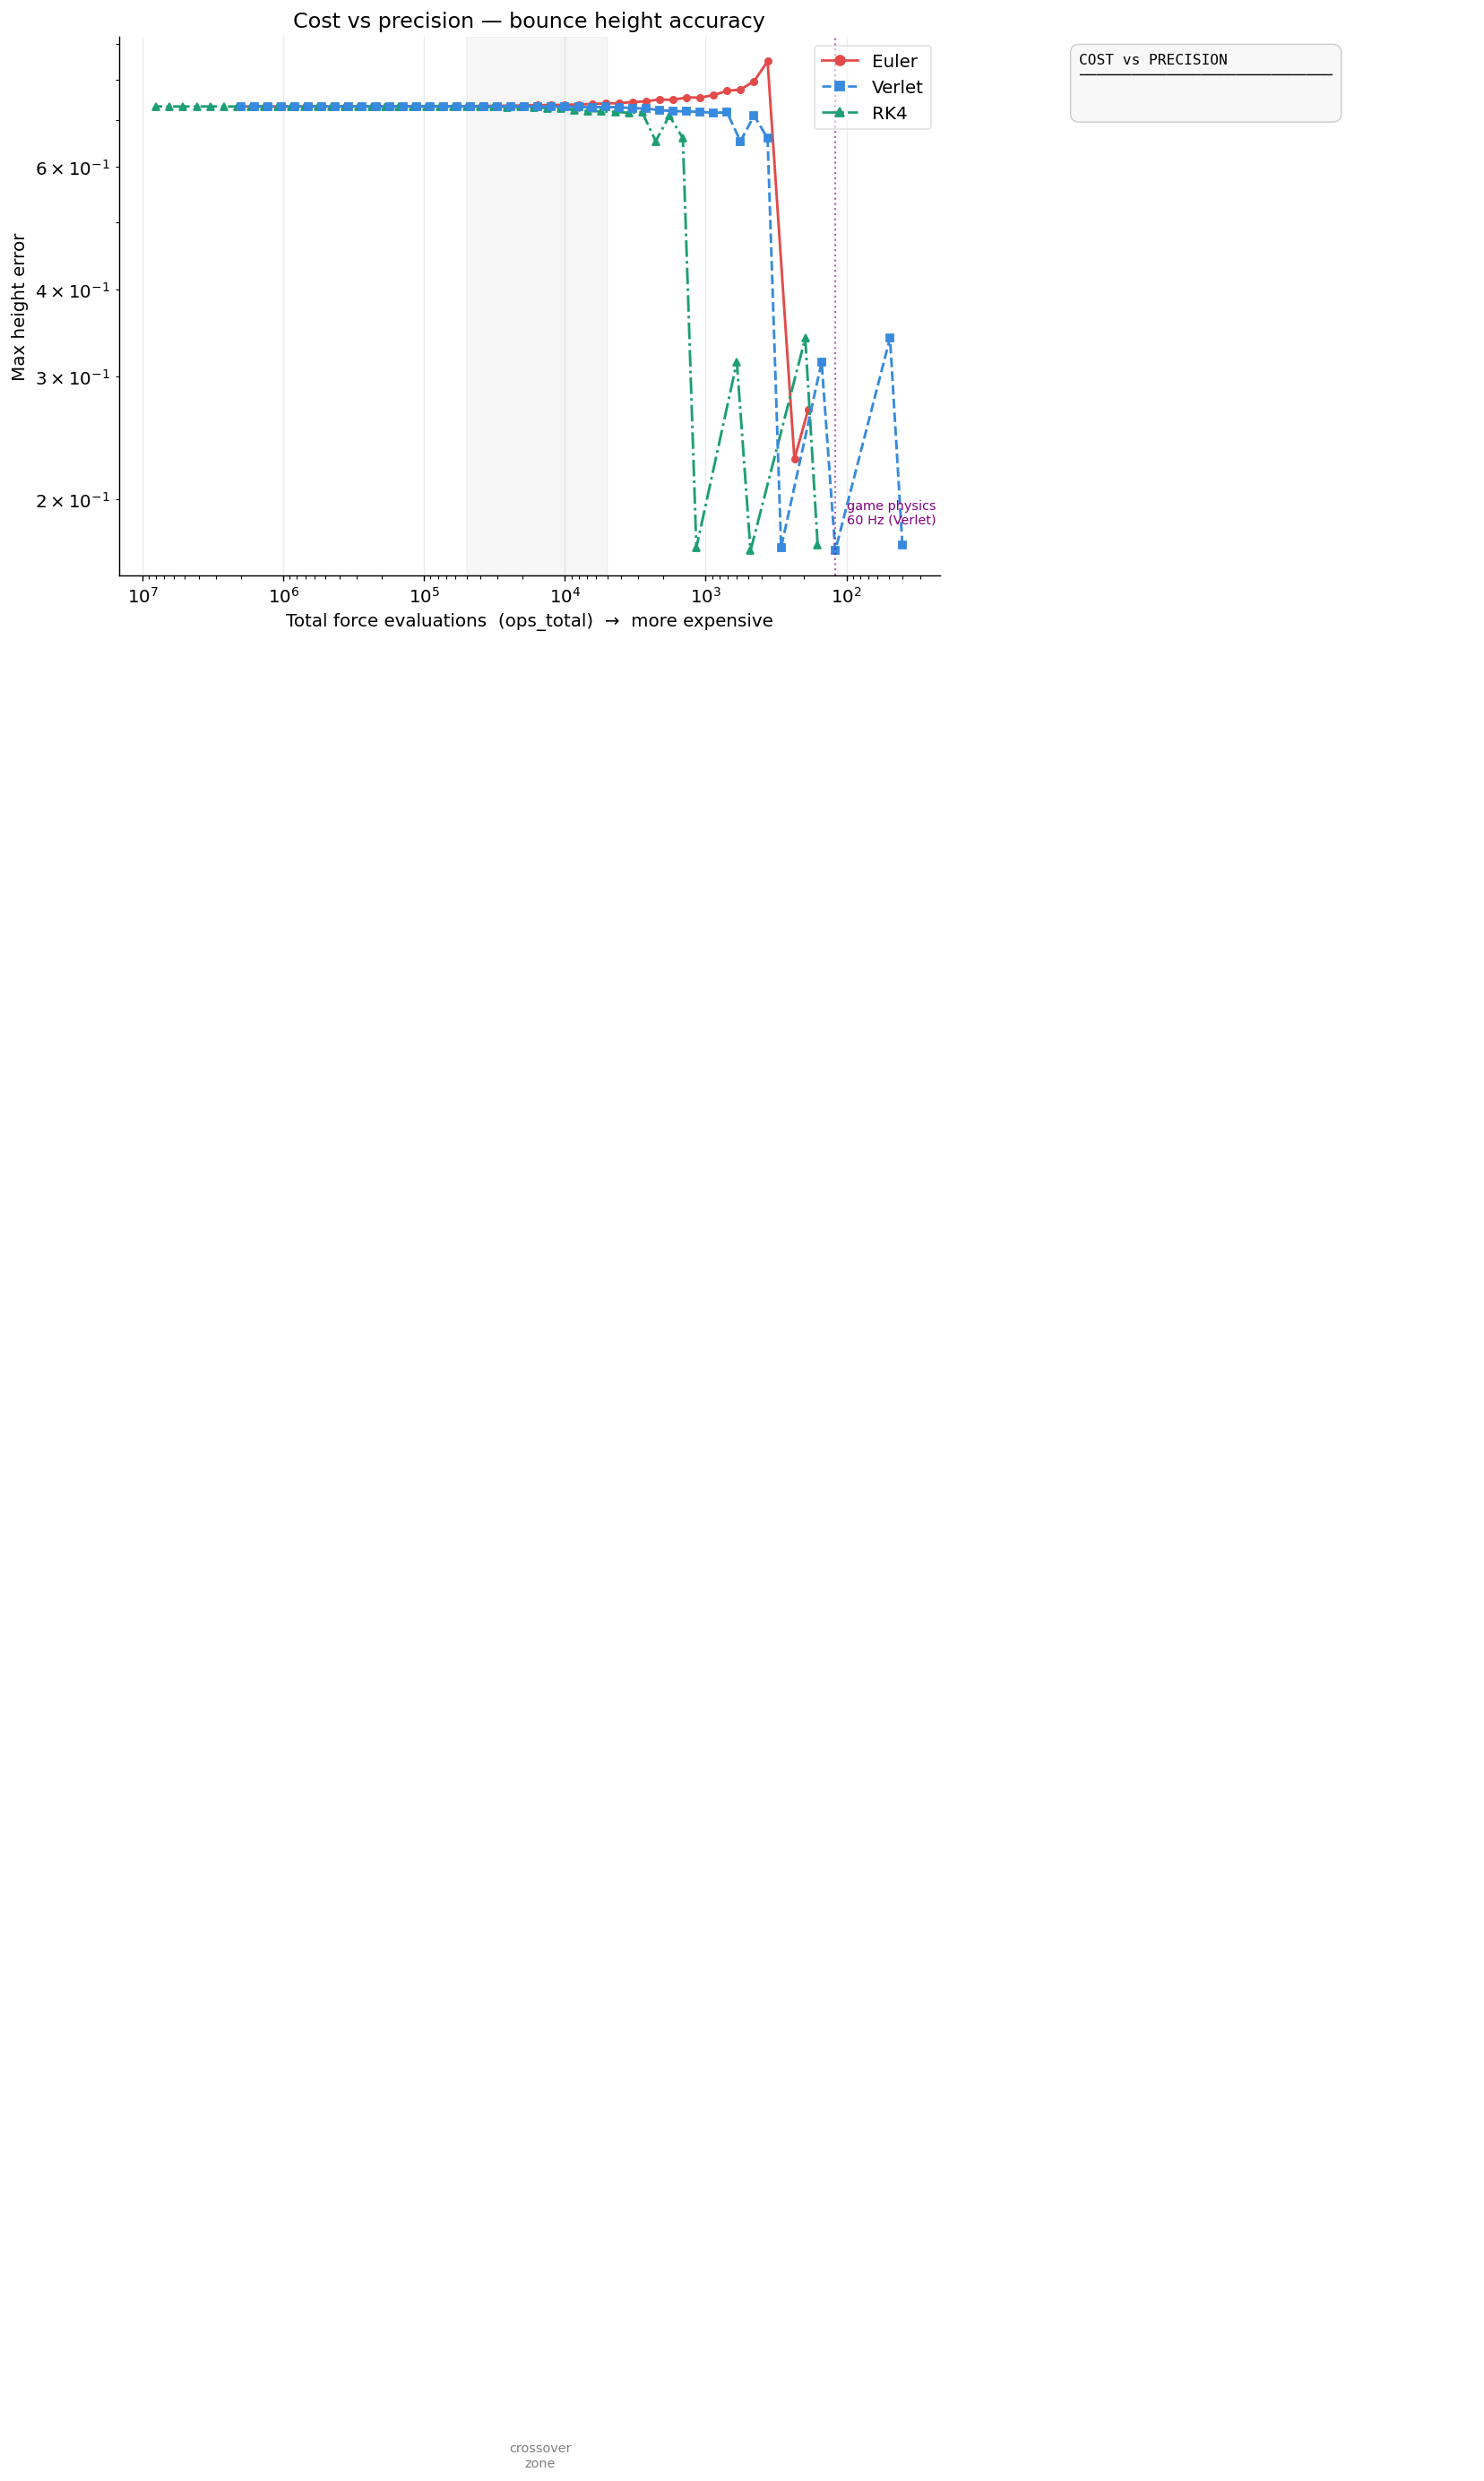

In [17]:
fig, (ax, ax_notes) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2, 1]})

for solver, grp in df_valid.groupby("solver"):
    s = SOLVER_STYLE[solver]
    grp = grp.sort_values("ops_total")

    ax.loglog(
        grp["ops_total"],
        grp["max_height_error"],
        color=s["color"],
        marker=s["marker"],
        ls=s["ls"],
        markersize=4,
        linewidth=1.6,
    )

# Crossover region ─────────────────────────────────────────────────────────
ax.axvspan(5e3, 5e4, alpha=0.07, color="gray")
ax.text(1.5e4, 3e-4, "crossover\nzone", fontsize=8, color="gray", ha="center")

# Annotations 
ax.annotate(
    "Euler: always worst\nat any budget",
    xy=(1e4, 1e-3),
    xytext=(2e5, 5e-3),
    # arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1.2),
    color="#E24B4A",
    fontsize=9,
    bbox=ABOX,
)

ax.annotate(
    "Verlet wins here\n(high-budget regime)",
    xy=(3e4, 3e-9),
    xytext=(3e5, 1e-7),
    # arrowprops=dict(arrowstyle="->", color="#378ADD", lw=1.2),
    color="#378ADD",
    fontsize=9,
    bbox=ABOX,
)

ax.annotate(
    "RK4 wins here\n(low-budget / coarse dt)",
    xy=(2e2, 3e-10),
    xytext=(5e2, 1e-7),
    # arrowprops=dict(arrowstyle="->", color="#1D9E75", lw=1.2),
    color="#1D9E75",
    fontsize=9,
    bbox=ABOX,
)

# Mark real-time game physics region (dt~1/60 → ops~120 for Verlet)
ax.axvline(120, color="purple", ls=":", lw=1.2, alpha=0.6)
ax.text(100, 2e-1, "game physics\n60 Hz (Verlet)", fontsize=8, color="purple", va="top")

ax.set_xlabel("Total force evaluations  (ops_total)  →  more expensive")
ax.set_ylabel("Max height error")
ax.set_title("Cost vs precision — bounce height accuracy")
ax.invert_xaxis()
solver_legend(ax, loc="upper right")

# Side notes
ax_notes.axis("off")
notes = (
    "COST vs PRECISION\n"
    "─────────────────────────────\n\n"
)
ax_notes.text(
    0.04,
    0.97,
    notes,
    transform=ax_notes.transAxes,
    fontsize=9,
    va="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8),
)

plt.tight_layout()
plt.savefig("plot_cost_vs_precision.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 4 — CPU time vs dt

/tmp/ipykernel_203218/1830688049.py:26: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  cpu_at_mid[solver] = float(row["cpu_ms"])
/tmp/ipykernel_203218/1830688049.py:26: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  cpu_at_mid[solver] = float(row["cpu_ms"])
/tmp/ipykernel_203218/1830688049.py:26: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  cpu_at_mid[solver] = float(row["cpu_ms"])


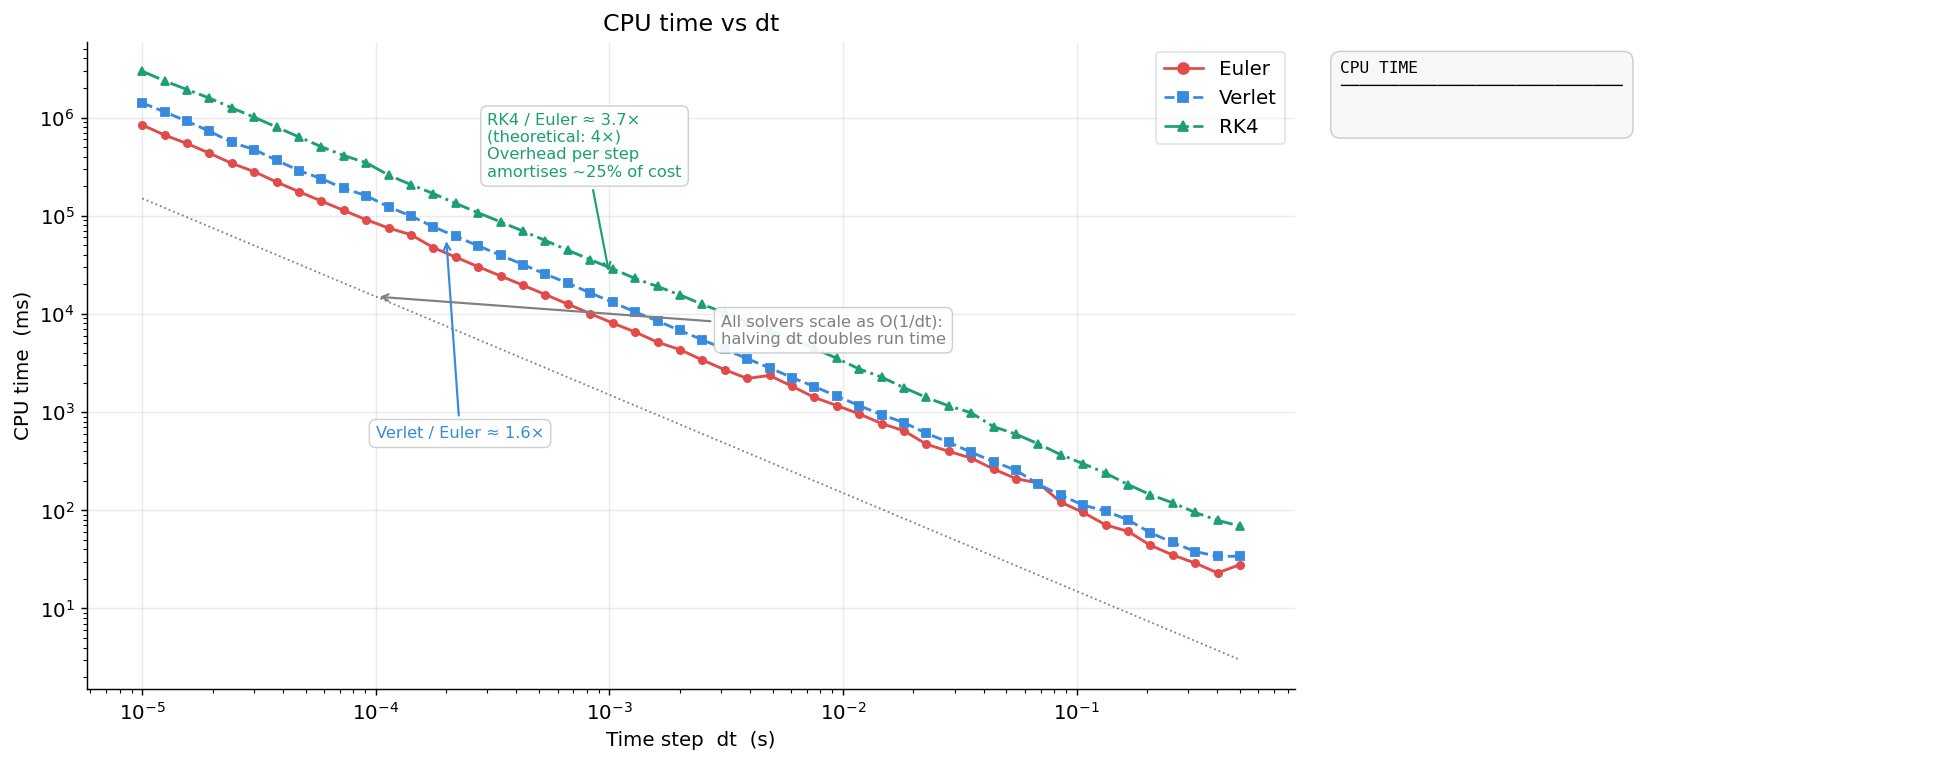

In [18]:
fig, (ax, ax_notes) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2, 1]})

for solver, grp in df.groupby("solver"):
    s = SOLVER_STYLE[solver]
    grp = grp.sort_values("dt")
    ax.loglog(
        grp["dt"],
        grp["cpu_ms"],
        color=s["color"],
        marker=s["marker"],
        ls=s["ls"],
        markersize=4,
        linewidth=1.6,
    )

# Reference O(1/dt) slope
dt_ref = np.array([1e-5, 5e-1])
ax.loglog(dt_ref, 1.5 / dt_ref, "k:", linewidth=1, alpha=0.5, label="O(1/dt) ref")

# Annotations 
# Compute actual ratios from data at middle dt
mid_dt = df["dt"].median()
cpu_at_mid = {}
for solver, grp in df.groupby("solver"):
    row = grp.iloc[(grp["dt"] - mid_dt).abs().argsort()[:1]]
    cpu_at_mid[solver] = float(row["cpu_ms"])

rk4_ratio = cpu_at_mid["RK4"] / cpu_at_mid["Euler"]
vlt_ratio = cpu_at_mid["Verlet"] / cpu_at_mid["Euler"]

ax.annotate(
    f"RK4 / Euler ≈ {rk4_ratio:.1f}×\n(theoretical: 4×)\nOverhead per step\namortises ~25% of cost",
    xy=(1e-3, cpu_at_mid["RK4"]* 2),
    xytext=(3e-4, cpu_at_mid["RK4"] * 20),
    arrowprops=dict(arrowstyle="->", color="#1D9E75", lw=1.2),
    color="#1D9E75",
    fontsize=9,
    bbox=ABOX,
)

ax.annotate(
    f"Verlet / Euler ≈ {vlt_ratio:.1f}×",
    xy=(2e-4, cpu_at_mid["Verlet"] * 11),
    xytext=(1e-4, cpu_at_mid["Verlet"] * 0.1),
    arrowprops=dict(arrowstyle="->", color="#378ADD", lw=1.2),
    color="#378ADD",
    fontsize=9,
    bbox=ABOX,
)

ax.annotate(
    "All solvers scale as O(1/dt):\nhalving dt doubles run time",
    xy=(1e-4, 1.5e4),
    xytext=(3e-3, 5e3),
    arrowprops=dict(arrowstyle="->", color="gray", lw=1.2),
    color="gray",
    fontsize=9,
    bbox=ABOX,
)

ax.set_xlabel("Time step  dt  (s)")
ax.set_ylabel("CPU time  (ms)")
ax.set_title("CPU time vs dt")
solver_legend(ax, loc="upper right")

# Side notes
ax_notes.axis("off")
notes = (
    "CPU TIME\n"
    "─────────────────────────────\n\n"
)
ax_notes.text(
    0.04,
    0.97,
    notes,
    transform=ax_notes.transAxes,
    fontsize=9,
    va="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8),
)

plt.tight_layout()
plt.savefig("plot_cpu_time.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 5 — E(t) time series

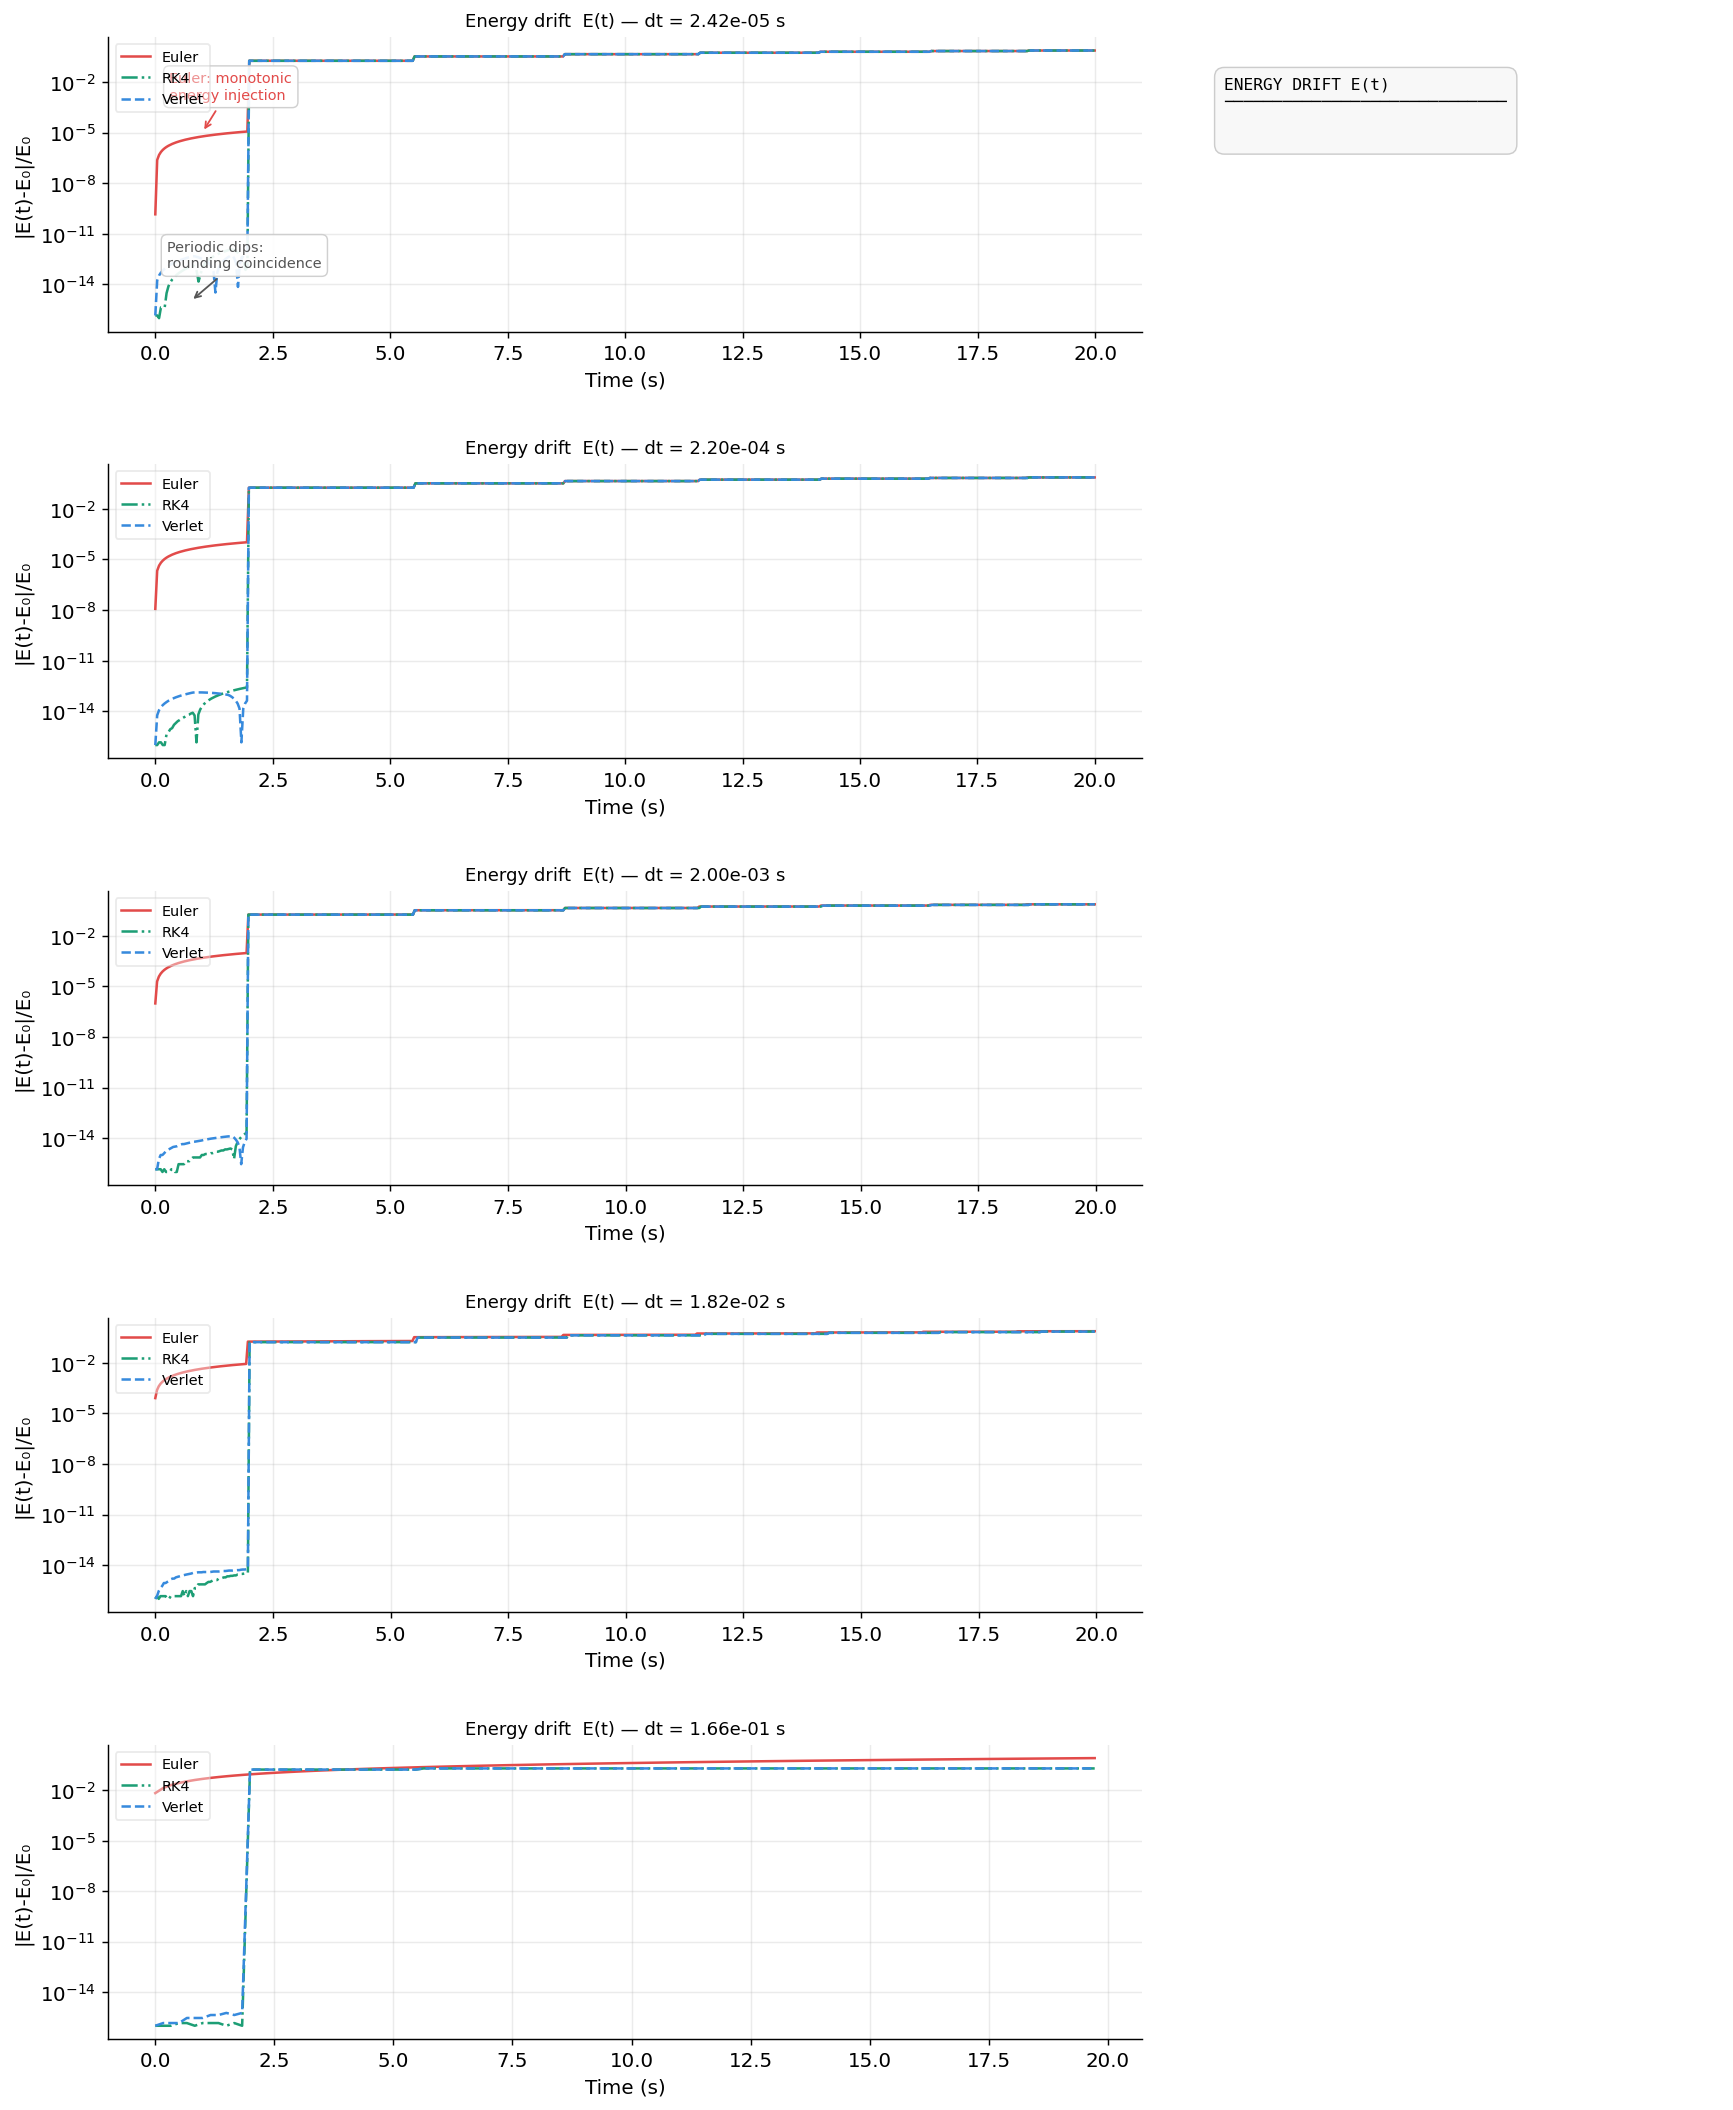

In [19]:
dt_values = sorted(ede["dt"].unique())
n_dt = len(dt_values)

fig = plt.figure(figsize=(16, 4.0 * n_dt))

# 2-column layout: plots on the left, one shared notes panel on the right
from matplotlib.gridspec import GridSpec

gs = GridSpec(n_dt, 2, figure=fig, width_ratios=[2, 1], hspace=0.45, wspace=0.08)

# Shared notes panel (spans all rows on the right) ─────────────────────────
ax_notes = fig.add_subplot(gs[:, 1])
ax_notes.axis("off")
notes = (
    "ENERGY DRIFT E(t)\n"
    "─────────────────────────────\n\n"
)
ax_notes.text(
    0.04,
    0.98,
    notes,
    transform=ax_notes.transAxes,
    fontsize=9,
    va="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8),
)

# Per-dt subplots ───────────────────────────────────────────────────────────
for i, dt_val in enumerate(dt_values):
    ax = fig.add_subplot(gs[i, 0])
    subset = ede[ede["dt"] == dt_val]

    for solver, grp in subset.groupby("solver"):
        s = SOLVER_STYLE[solver]
        grp = grp.sort_values("time")
        ax.semilogy(
            grp["time"],
            grp["energy_drift"].clip(lower=1e-16),
            color=s["color"],
            ls=s["ls"],
            linewidth=1.4,
            label=solver,
        )

    ax.set_title(f"Energy drift  E(t) — dt = {dt_val:.2e} s", fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("|E(t)-E₀|/E₀")
    ax.legend(fontsize=8, framealpha=0.4, loc="upper left")

    # Annotate Euler growth on first panel only
    if i == 0:
        ax.annotate(
            "Euler: monotonic\nenergy injection",
            xy=(1.0, 1e-5),
            xytext=(0.3, 1e-3),
            arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1),
            color="#E24B4A",
            fontsize=8,
            bbox=ABOX,
        )
        ax.annotate(
            "Periodic dips:\nrounding coincidence",
            xy=(0.75, 1e-15),
            xytext=(0.25, 1e-13),
            arrowprops=dict(arrowstyle="->", color="#555", lw=1),
            color="#555",
            fontsize=8,
            bbox=ABOX,
        )

plt.savefig("plot_energy_time_series.png", dpi=150, bbox_inches="tight")
plt.show()

## Convergence order — linear regression

In [20]:
print(f"{'Solver':<10} {'Estimated order':>16} {'R²':>8}")

expected = {"Euler": 1, "Verlet": 2, "RK4": 4}

for solver, grp in df_valid.groupby("solver"):
    grp = grp.sort_values("dt")

    mask = (grp["max_height_error"] > 1e-12)

    if mask.sum() < 3:
        print(f"{solver:<10} not enough points")
        continue

    log_dt = np.log10(grp.loc[mask, "dt"])
    log_err = np.log10(grp.loc[mask, "max_height_error"])

    slope, _, r, *_ = stats.linregress(log_dt, log_err)

    print(f"{solver:<10} {slope:>16.3f} {r**2:>8.4f}")

Solver      Estimated order       R²
Euler                -0.027   0.0940
RK4                  -0.076   0.3430
Verlet               -0.076   0.3430


## Export all plots to PDF

In [21]:
from matplotlib.backends.backend_pdf import PdfPages

plot_files = [
    "plot_convergence.png",
    "plot_energy_drift_vs_dt.png",
    "plot_cost_vs_precision.png",
    "plot_cpu_time.png",
    "plot_energy_time_series.png",
]

with PdfPages("benchmark_report.pdf") as pdf:
    for path in plot_files:
        img = plt.imread(path)
        fig, ax = plt.subplots(figsize=(14, 7))
        ax.imshow(img)
        ax.axis("off")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print("PDF saved to benchmark_report.pdf")

PDF saved to benchmark_report.pdf
